In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats._mstats_basic import winsorize
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, PowerTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import umap
import trimap
import pacmap

RANDOM_STATE = 318

In [139]:
def run_eda(df):
    print("\n--- Разведочный анализ (EDA) ---")
    print(df.head())
    print("\nТипы данных:")
    print(df.dtypes)
    print("\nПропуски:")
    print(df.isna().sum())


In [140]:
def preprocess_dataset(df, target_col=None):
    X = df.copy()
    y_true = None

    # извлечение меток, если есть
    if target_col is not None:
        if isinstance(target_col, int):
            y_true = X.iloc[:, target_col]
            X = X.drop(X.columns[target_col], axis=1)
        else:
            y_true = X[target_col]
            X = X.drop(columns=[target_col])

        if y_true.dtype == "object":
            y_true = LabelEncoder().fit_transform(y_true)

    # кодирование категориальных полей
    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    # обработка пропусков
    X = X.fillna(X.mean(numeric_only=True))

    # ограничение размера (для t-SNE)
    if len(X) > 5000:
        X = X.sample(5000, random_state=RANDOM_STATE)
        if y_true is not None:
            y_true = y_true[X.index]

    # масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X, X_scaled, y_true


In [141]:
def find_optimal_k(X_scaled):
    inertia = []
    sil_km = []
    sil_agg = []

    K = range(2, 11)
    print("\n--- Поиск оптимального числа кластеров (2..10) ---")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for k in K:
            # KMeans
            km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels_km = km.fit_predict(X_scaled)
            inertia.append(km.inertia_)
            sil_km.append(silhouette_score(X_scaled, labels_km))

            # Agglomerative
            agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
            labels_agg = agg.fit_predict(X_scaled)
            sil_agg.append(silhouette_score(X_scaled, labels_agg))

    # графики
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    ax[0].plot(K, inertia, "bo-")
    ax[0].set_title("Метод локтя (KMeans)")
    ax[0].set_xlabel("k")

    ax[1].plot(K, sil_km, "go-", label="KMeans")
    ax[1].plot(K, sil_agg, "rx--", label="Agglomerative")
    ax[1].set_title("Silhouette Score")
    ax[1].legend()

    plt.show()

    # выбор алгоритма и k
    best_km = max(sil_km)
    best_agg = max(sil_agg)

    if best_km >= best_agg:
        return "KMeans", K[np.argmax(sil_km)]
    else:
        return "Agglomerative", K[np.argmax(sil_agg)]


In [142]:
def train_best_clustering(X_scaled, algo_name, k):
    if algo_name == "KMeans":
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X_scaled)

    else:
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(X_scaled)

    return labels


In [143]:
def compute_embeddings(X_scaled):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        tsne = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate='auto',
            max_iter=1500,
            init='pca',
            random_state=RANDOM_STATE
        ).fit_transform(X_scaled)

        umap_emb = umap.UMAP(
            n_neighbors=30,
            min_dist=0.1,
            n_components=2,
            random_state=RANDOM_STATE
        ).fit_transform(X_scaled)

        np.random.seed(RANDOM_STATE)
        trimap_emb = trimap.TRIMAP(
            n_dims=2,
            n_inliers=15,
            n_outliers=5,
            n_random=5,
            n_iters=400,
            lr=500,
            apply_pca=True
        ).fit_transform(X_scaled)

        pacmap_emb = pacmap.PaCMAP(
            n_components=2,
            MN_ratio=0.5,
            FP_ratio=2.0,
            random_state=RANDOM_STATE
        ).fit_transform(X_scaled)

    return tsne, umap_emb, trimap_emb, pacmap_emb


In [144]:
def plot_all_embeddings(X_scaled, labels):
    unique_labels = np.unique(labels)
    palette = sns.color_palette("viridis", len(unique_labels))

    tsne, umap_emb, trimap_emb, pacmap_emb = compute_embeddings(X_scaled)

    def compute_centers(embedding, labels):
        return np.vstack([
            embedding[labels == c].mean(axis=0)
            for c in unique_labels
        ])

    centers_tsne   = compute_centers(tsne, labels)
    centers_umap   = compute_centers(umap_emb, labels)
    centers_trimap = compute_centers(trimap_emb, labels)
    centers_pacmap = compute_centers(pacmap_emb, labels)

    def plot_emb(ax, emb, centers, title):
        sns.scatterplot(
            x=emb[:, 0], y=emb[:, 1],
            hue=labels,
            palette=palette,
            hue_order=unique_labels,
            s=18, ax=ax, legend='full'
        )
        ax.scatter(
            centers[:, 0], centers[:, 1],
            c='white', edgecolors='black',
            s=200, marker='X', linewidths=1.5, zorder=10
        )
        ax.set_title(title)

    # ----- Построение графиков -----
    fig, ax = plt.subplots(2, 2, figsize=(16, 12))

    plot_emb(ax[0, 0], tsne, centers_tsne, "t-SNE")
    plot_emb(ax[0, 1], umap_emb, centers_umap, "UMAP")
    plot_emb(ax[1, 0], trimap_emb, centers_trimap, "TriMAP")
    plot_emb(ax[1, 1], pacmap_emb, centers_pacmap, "PaCMAP")

    plt.tight_layout()
    plt.show()


In [145]:
def profile_clusters(X, labels):
    print("\n--- Профилирование кластеров ---")
    df_prof = pd.concat(
    [pd.DataFrame(X, columns=X.columns),
     pd.Series(labels, name="cluster")],
    axis=1
    ).copy()
    print(df_prof.groupby("cluster").mean())

In [146]:
def analyze_dataset(df, name, target_col=None):
    print(f"\n=== DATASET: {name} ===")
    run_eda(df)

    X, X_scaled, y_true = preprocess_dataset(df, target_col)

    algo_name, k = find_optimal_k(X_scaled)
    print(f"\nЛучший алгоритм: {algo_name}, k={k}")

    labels = train_best_clustering(X_scaled, algo_name, k)

    if y_true is not None:
        ari = adjusted_rand_score(y_true, labels)
        print(f"\nARI = {ari:.4f}")

    plot_all_embeddings(X_scaled, labels)
    profile_clusters(X, labels)



=== DATASET: Soybean Large ===

--- Разведочный анализ (EDA) ---
                      0  1  2  3  4  5  6  7  8  9   ... 26 27  28 29 30 31  \
0  diaporthe-stem-canker  6  0  2  1  0  1  1  1  0  ...  0  0   0  4  0  0   
1  diaporthe-stem-canker  4  0  2  1  0  2  0  2  1  ...  0  0   0  4  0  0   
2  diaporthe-stem-canker  3  0  2  1  0  1  0  2  1  ...  0  0   0  4  0  0   
3  diaporthe-stem-canker  3  0  2  1  0  1  0  2  0  ...  0  0   0  4  0  0   
4  diaporthe-stem-canker  6  0  2  1  0  2  0  1  0  ...  0  0   0  4  0  0   

  32 33 34 35  
0  0  0  0  0  
1  0  0  0  0  
2  0  0  0  0  
3  0  0  0  0  
4  0  0  0  0  

[5 rows x 36 columns]

Типы данных:
0     object
1     object
2     object
3     object
4     object
5     object
6     object
7     object
8     object
9     object
10    object
11    object
12     int64
13    object
14    object
15    object
16    object
17    object
18    object
19    object
20    object
21    object
22    object
23    object
24    object
2

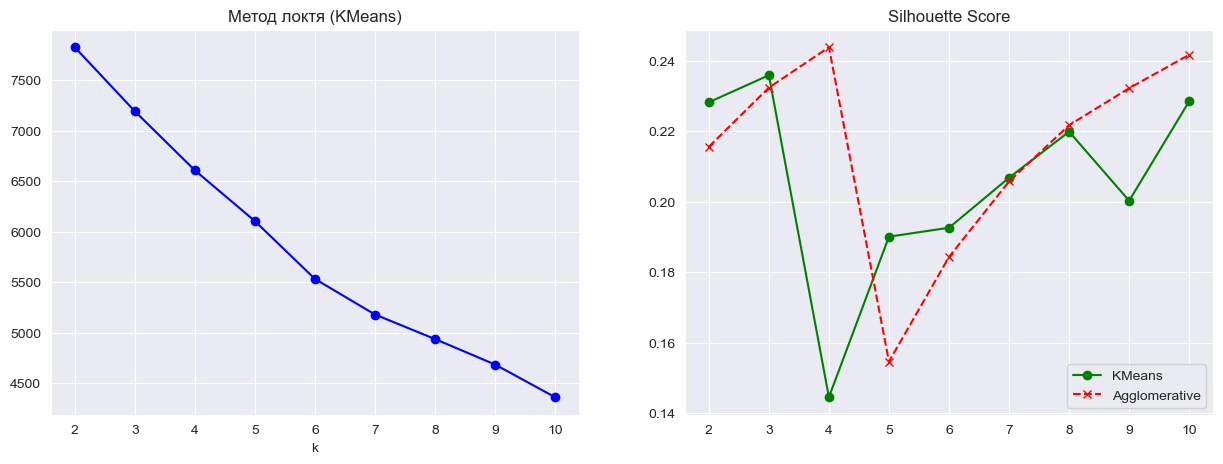


Лучший алгоритм: Agglomerative, k=4

ARI = 0.0221


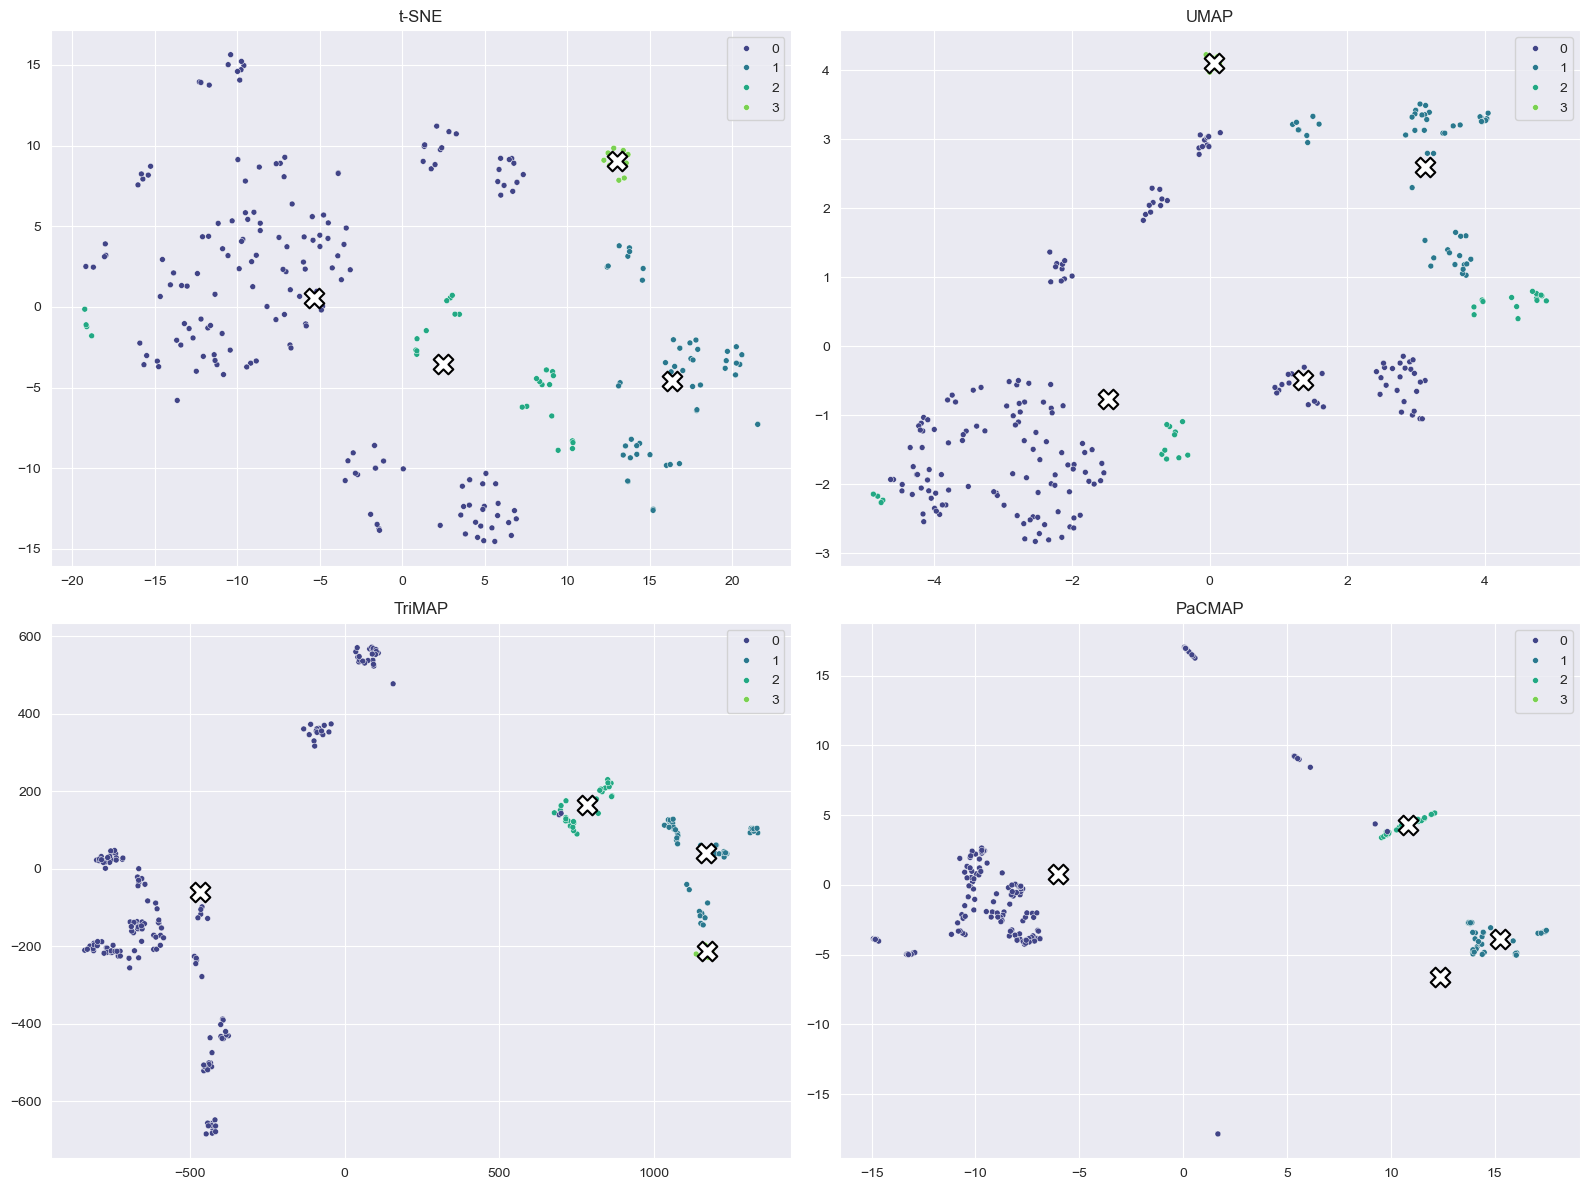


--- Профилирование кластеров ---
               0         2         3         4         5         6         7   \
cluster                                                                         
0.0      4.850299  0.425150  1.520958  1.143713  0.179641  1.898204  1.850299   
1.0      9.972973  0.540541  1.891892  0.567568  0.297297  1.621622  0.864865   
2.0      3.964286  0.392857  1.607143  1.035714  0.321429  1.750000  1.535714   
3.0      6.000000  0.000000  0.000000  1.600000  0.500000  1.600000  2.500000   

               8         9         10  ...       26   27        28        29  \
cluster                                ...                                     
0.0      0.694611  0.610778  1.017964  ...  0.11976  0.0  0.239521  0.526946   
1.0      1.351351  0.351351  1.108108  ...  0.00000  0.0  1.135135  2.486486   
2.0      0.678571  0.428571  1.071429  ...  0.00000  0.0  0.035714  0.071429   
3.0      1.000000  0.500000  0.900000  ...  2.00000  1.0  0.000000  3.000000   

In [147]:
df_soy = pd.read_csv('soybean-large.data', header=None)
df_soy = df_soy.replace('?', np.nan).dropna()
analyze_dataset(df_soy, "Soybean Large",target_col=1)


=== DATASET: Benign Traffic ===

--- Разведочный анализ (EDA) ---
   MI_dir_L5_weight  MI_dir_L5_mean  MI_dir_L5_variance  MI_dir_L3_weight  \
0          1.000000       60.000000            0.000000          1.000000   
1          1.000000       70.000000            0.000000          1.000000   
2          1.000008       89.999836            0.003289          1.000889   
3          1.000000      322.000000            0.000000          1.000000   
4          1.784845      328.723273           35.476876          1.864710   

   MI_dir_L3_mean  MI_dir_L3_variance  MI_dir_L1_weight  MI_dir_L1_mean  \
0       60.000000            0.000000          1.000000       60.000000   
1       70.000000            0.000000          1.000000       70.000000   
2       89.982231            0.355061          1.096162       88.245473   
3      322.000000            0.000000          1.000000      322.000000   
4      328.435318           35.810498          1.952701      328.145333   

   MI_dir_L1_varian

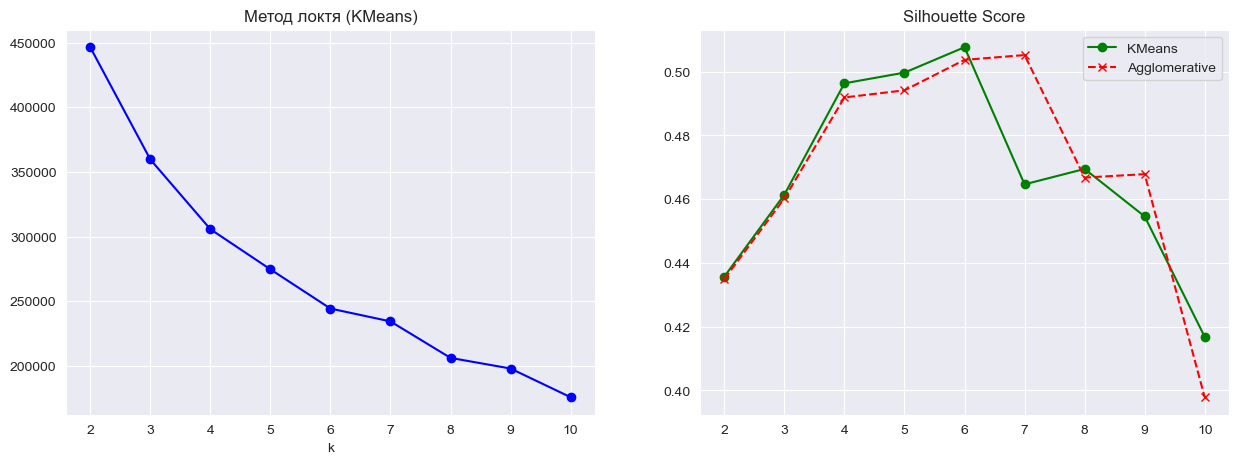


Лучший алгоритм: KMeans, k=6


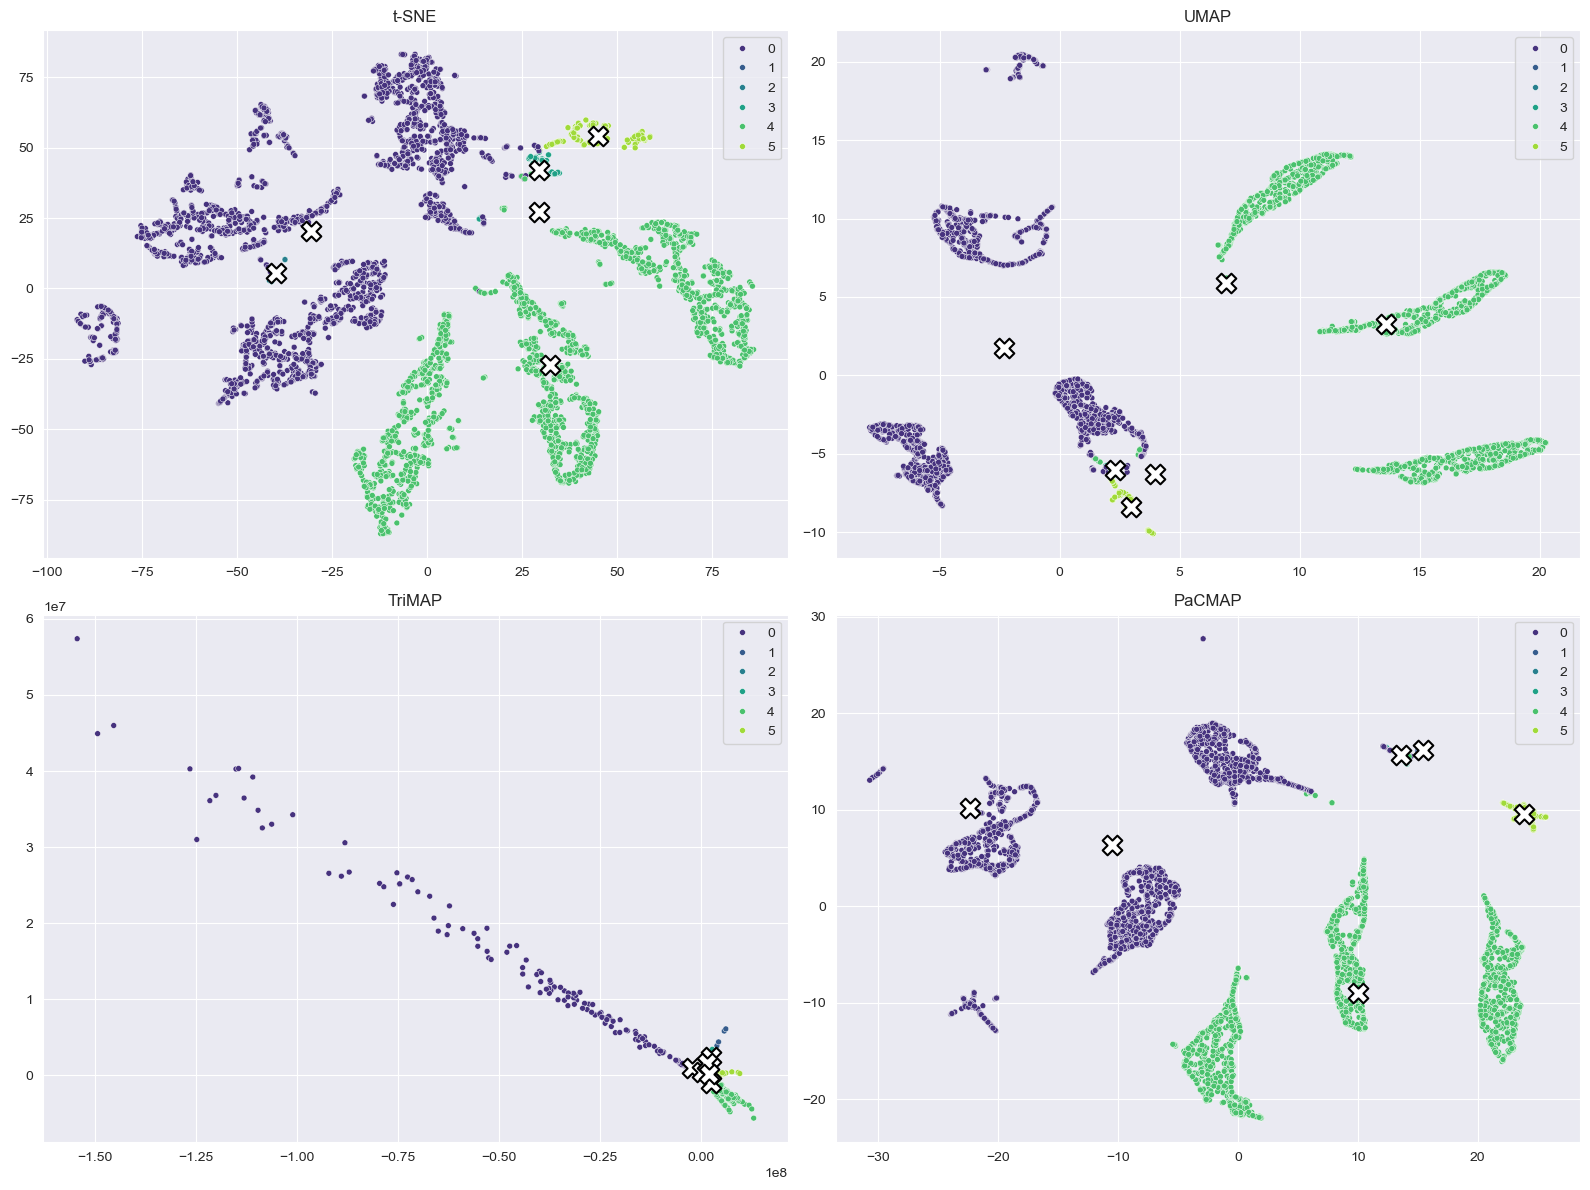


--- Профилирование кластеров ---
         MI_dir_L5_weight  MI_dir_L5_mean  MI_dir_L5_variance  \
cluster                                                         
0.0              1.570734      280.457402          901.129379   
1.0             16.067945      136.751898        32652.468840   
2.0              2.999612      456.336827          374.174630   
3.0              1.424961      361.223499          110.294279   
4.0              1.679781      269.748555         1565.768723   
5.0              2.287900      249.781442         2127.421016   

         MI_dir_L3_weight  MI_dir_L3_mean  MI_dir_L3_variance  \
cluster                                                         
0.0              1.611886      282.800299         1233.553473   
1.0             17.283503      135.762090        32073.910890   
2.0              2.999771      456.334966          374.377184   
3.0              1.426525      361.185230          120.147691   
4.0              1.749121      271.799436         1747.

In [148]:
df_traffic = pd.read_csv('benign_traffic.csv')
analyze_dataset(df_traffic, "Benign Traffic")


=== DATASET: Mammoth ===

--- Разведочный анализ (EDA) ---
        x        y       z
0  58.823  228.407  79.843
1  59.197  228.642  77.478
2  58.734  228.931  78.515
3  59.043  228.693  78.571
4  59.223  228.667  78.611

Типы данных:
x    float64
y    float64
z    float64
dtype: object

Пропуски:
x    0
y    0
z    0
dtype: int64

--- Поиск оптимального числа кластеров (2..10) ---


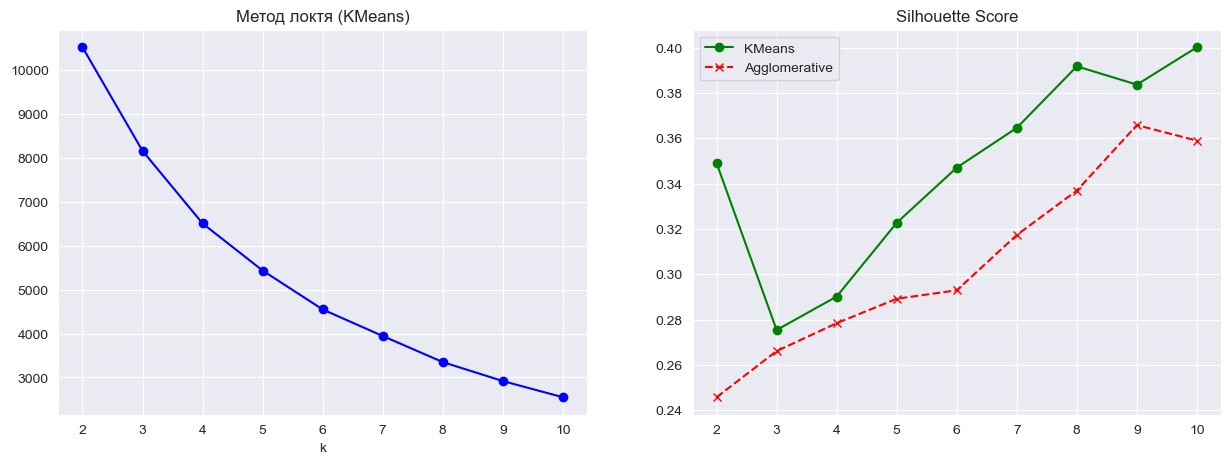


Лучший алгоритм: KMeans, k=10


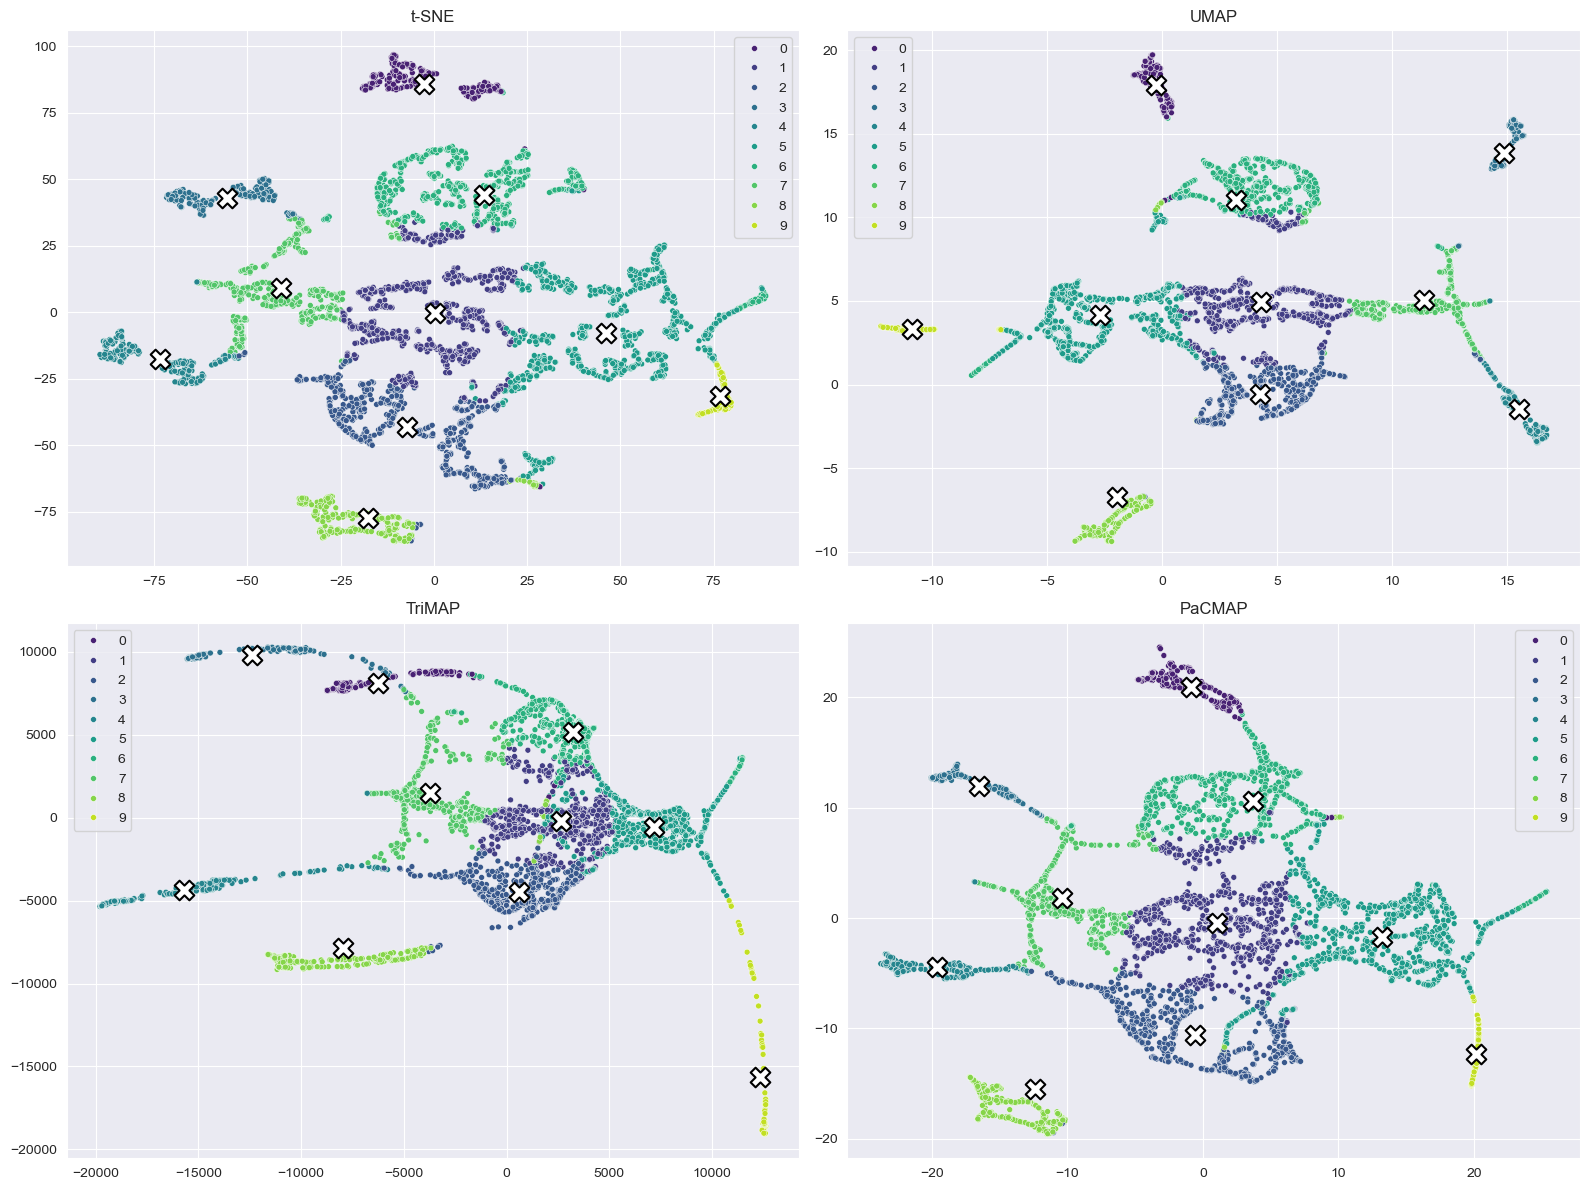


--- Профилирование кластеров ---
                  x           y           z
cluster                                    
0.0       84.381333  221.388667  120.634333
1.0       93.472200  215.020000   79.611000
2.0       65.450600  180.398000   86.931400
3.0      101.276000  227.444000   86.127000
4.0       71.022000  240.455000   92.274000
5.0       56.582500  199.766167   81.191500
6.0       71.312000  200.886500   66.053000
7.0       76.405500  215.985500   87.487500
8.0      109.311000  206.518000  107.069000
9.0       97.499500  214.341000  111.394500


In [149]:
df_mammoth = pd.read_csv('mammoth.csv')
analyze_dataset(df_mammoth, "Mammoth")